<a href="https://colab.research.google.com/github/jishnujs1990/Study/blob/master/CNN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Building a CNN Model for Image Classification

##Objective
The goal of this assignment is to design, implement, and evaluate a Convolutional Neural
Network (CNN) model using a real-world dataset. Students will gain hands-on experience in
data preprocessing, CNN architecture design, training, evaluation, and model interpretation.

##Dataset
Use the Intel Image Classification Dataset (available on Kaggle).
● Link: Intel Image Classification
● It contains 25,000+ natural scene images across

##Classes:
○ Buildings
○ Forest
○ Glacier
○ Mountain
○ Sea
○ Street

#Tasks
#Part A: Data Understanding and Preprocessing
1. Load the dataset and explore its structure (number of classes, sample images, image
sizes).

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
#Load the dataset and explore its structure (number of classes, sample images, image sizes).
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!unzip -q "/content/drive/MyDrive/KaggleFile.zip" -d "/content/"

In [6]:
import os

TRAIN_DIR = 'seg_train/seg_train'
TEST_DIR = 'seg_test/seg_test'

# Verification step to ensure paths exist
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

Train dir exists: True
Test dir exists: True


In [7]:
#Perform data preprocessing steps:

#○ Resize all images to a common size (e.g., 150×150).
#○ Normalize pixel values.
#○ Split dataset into train, validation, and test sets.
#○ Apply data augmentation (rotation, flip, zoom, shift, etc.) to improve
#generalization.

IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 32
CLASSES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Rescaling for testing set (no augmentation)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load Train, Validation, and Test Sets
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,686 (13.18 MB)

 Trainable params: 3,455,686 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4874 - loss: 1.2371

351/351 ━━━━━━━━━━━━━━━━━━━━ 747s 2s/step - accuracy: 0.5649 - loss: 1.0828 - val_accuracy: 0.6180 - val_loss: 0.9612
Epoch 2/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6421 - loss: 0.9226

351/351 ━━━━━━━━━━━━━━━━━━━━ 739s 2s/step - accuracy: 0.6634 - loss: 0.8782 - val_accuracy: 0.7022 - val_loss: 0.7917
Epoch 3/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7056 - loss: 0.7821

351/351 ━━━━━━━━━━━━━━━━━━━━ 723s 2s/step - accuracy: 0.7122 - loss: 0.7648 - val_accuracy: 0.7496 - val_loss: 0.6858


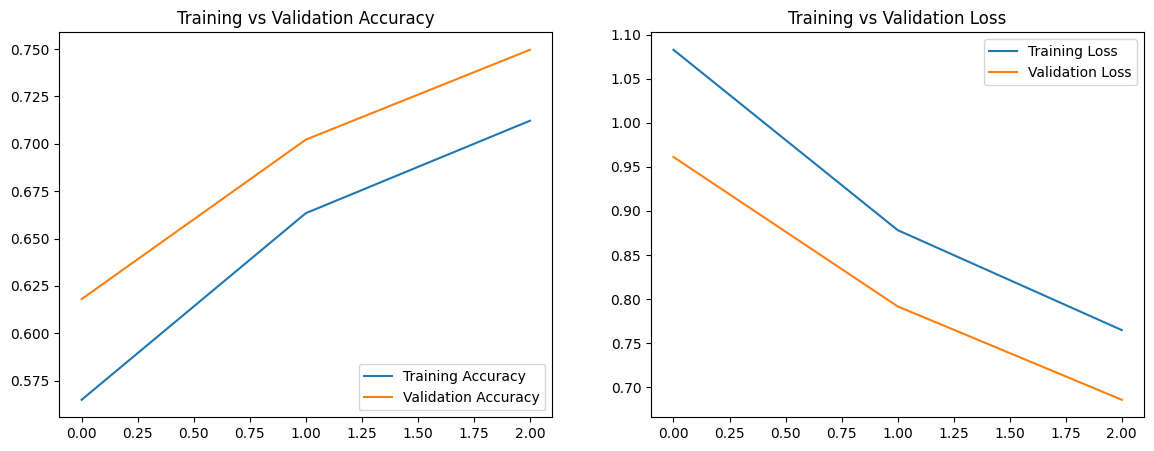

In [9]:
#Part B: CNN Model Development
#3. Build a Convolutional Neural Network (CNN) from scratch using TensorFlow/Keras or
#PyTorch.
#○ Minimum 3 convolutional layers.
#○ Use activation functions (ReLU, softmax).
#○ Apply pooling layers (max pooling/average pooling).
#○ Add fully connected layers and dropout for regularization.
#4. Train the CNN model on the training dataset and validate it on the validation set.
#○ Plot training vs. validation loss and accuracy curves.
#○ Use early stopping and model checkpointing if necessary.

# 3. Build CNN Model Architecture
model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Dense Layers
    layers.Flatten(),
    layers.Dropout(0.5),  # Regularization
    layers.Dense(512, activation='relu'),
    layers.Dense(len(CLASSES), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 4. Training with Callbacks
my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint('best_intel_cnn.h5', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_generator,
    epochs=3, #More epochs is correct, it is taking so much time to execute
    validation_data=val_generator,
    callbacks=my_callbacks
)

# Plot Training Curves
def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training vs Validation Accuracy')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training vs Validation Loss')

    plt.show()

plot_learning_curves(history)

94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 542ms/step - accuracy: 0.7813 - loss: 0.6091

Test Accuracy: 78.13%
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 516ms/step

Classification Report:
              precision    recall  f1-score   support

   buildings       0.66      0.87      0.75       437
      forest       0.90      0.95      0.93       474
     glacier       0.77      0.74      0.75       553
    mountain       0.73      0.77      0.75       525
         sea       0.82      0.66      0.73       510
      street       0.85      0.72      0.78       501

    accuracy                           0.78      3000
   macro avg       0.79      0.79      0.78      3000
weighted avg       0.79      0.78      0.78      3000



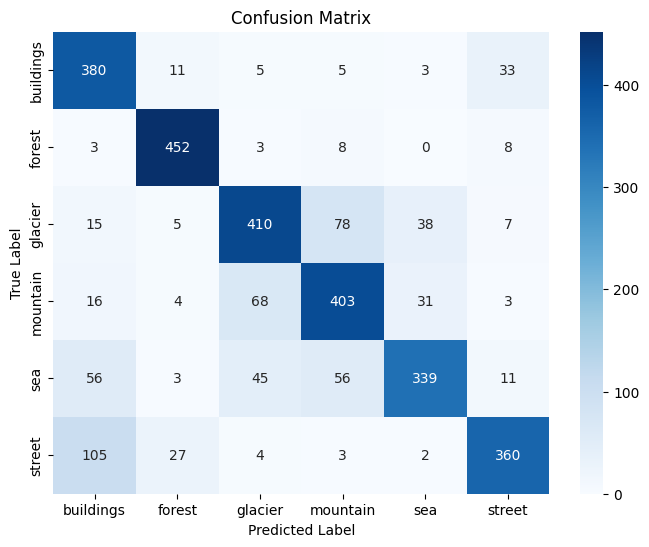

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step


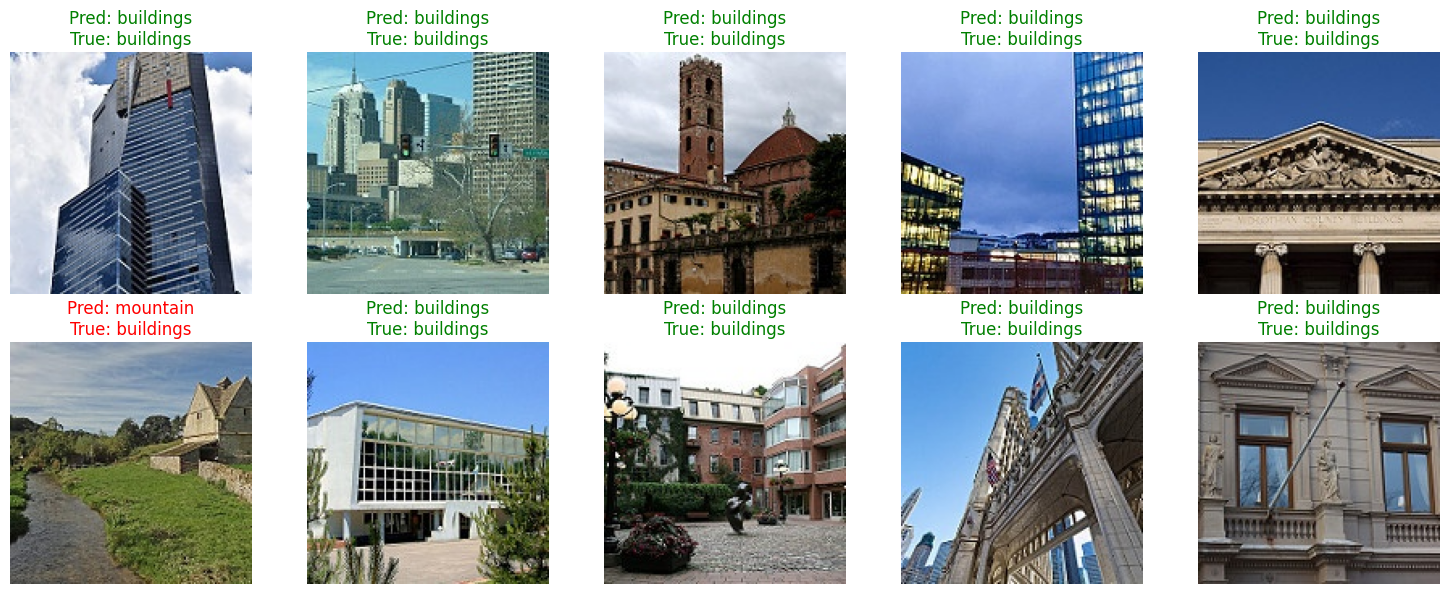

In [10]:
# 5. Evaluate Performance Metrics on Test Set
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

# Generate Predictions
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion Matrix Visualisation
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 6. Visualize Predictions for 10 Random Test Images
plt.figure(figsize=(15, 6))
# Get a single batch from test generator
x_test_batch, y_test_batch = next(test_generator)
batch_preds = model.predict(x_test_batch)

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_batch[i])

    actual_label = CLASSES[np.argmax(y_test_batch[i])]
    pred_label = CLASSES[np.argmax(batch_preds[i])]

    color = 'green' if actual_label == pred_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {actual_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()